In [1]:
#Final project code

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [3]:
#See if the data is imbalanced
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
print(df.isnull().sum().sum()) #check for missing values

0


In [5]:
print(df.duplicated().sum()) #check for duplicates

1081


In [6]:
df = df.drop_duplicates() #drop duplicates

In [7]:
df.info() #check if duplicated were dropped

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

In [8]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['amount_scaled'] = scaler.fit_transform(df[['Amount']])

In [9]:
#Split the data
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']
#Since the dataset is highly imbalanced, I used "stratify=y" to preserve the class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [10]:
y_train.value_counts(normalize=True)

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

In [11]:
y_test.value_counts(normalize=True)

Class
0    0.998332
1    0.001668
Name: proportion, dtype: float64

In [12]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     84976
           1       0.04      0.89      0.08       142

    accuracy                           0.97     85118
   macro avg       0.52      0.93      0.53     85118
weighted avg       1.00      0.97      0.98     85118



E:\Anaconda\anaconda_files\envs\bioinfo\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.96      0.73      0.83       142

    accuracy                           1.00     85118
   macro avg       0.98      0.86      0.91     85118
weighted avg       1.00      1.00      1.00     85118



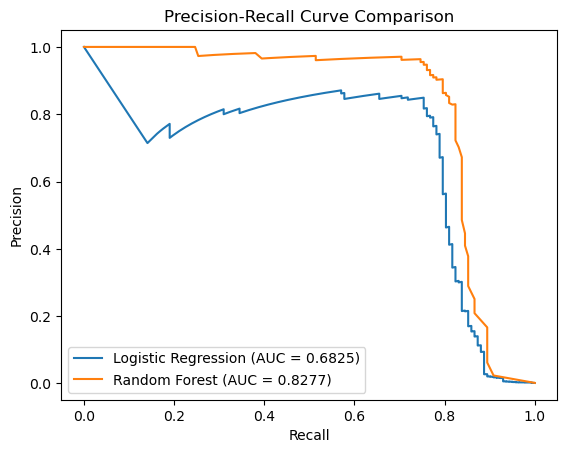

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

#Logistic Regression
y_scores_lr = model.predict_proba(X_test)[:, 1]
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_scores_lr)
auc_lr = auc(recall_lr, precision_lr)

#Random Forest
y_scores_rf = rf_model.predict_proba(X_test)[:, 1]
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_scores_rf)
auc_rf = auc(recall_rf, precision_rf)

#Plot
plt.figure()

plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()

plt.show()

In [15]:
# List the coefficients based on the absolute values
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df.head(10))

          Feature  Coefficient
14            V14    -1.323644
12            V12    -0.806561
22            V22     0.805327
4              V4     0.801095
15            V15    -0.697841
25            V25    -0.645503
10            V10    -0.603590
17            V17    -0.585651
30  amount_scaled     0.534905
8              V8    -0.504228


In [16]:
# List the importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns,'Importance': importances}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

   Feature  Importance
14     V14    0.187372
10     V10    0.137044
12     V12    0.115703
4       V4    0.087400
17     V17    0.084569
11     V11    0.061060
3       V3    0.054523
7       V7    0.039532
16     V16    0.035995
9       V9    0.020291


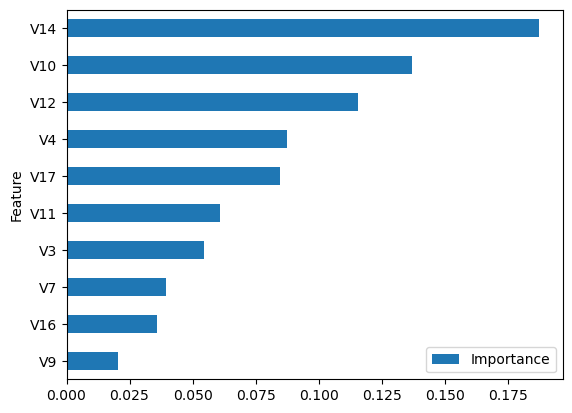

In [17]:
# Visualize the importances
feature_importance_df.head(10).plot(x='Feature', y='Importance', kind='barh')
plt.gca().invert_yaxis()
plt.show()